# DBSCAN

**DBSCAN** (Density-based spatial clustering of applications with noise — «плотностной алгоритм пространственной кластеризации с шумом»)

In [1]:
# Установка зависимостей
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# 1. Загрузка данных
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t2_customer_segmentation.csv")

print(f"Типы данных в датасете: \n{df.dtypes}\n")
print(f"Количество пропусков по столбцам: \n{df.isna().sum()}\n")

print(f"Определяем возможные значения в колонке education: \n{df['education'].value_counts()}\n")
print(f"Определяем возможные значения в колонке marital_status: \n{df['marital_status'].value_counts()}\n")

Типы данных в датасете: 
id                            int64
year_birth                    int64
education                       str
marital_status                  str
income                      float64
kids                          int64
date_first_purchase             str
days_since_last_purchase      int64
num_purchases_at_shop         int64
num_web_purchases             int64
avg_purchase_sum            float64
dtype: object

Количество пропусков по столбцам: 
id                          0
year_birth                  0
education                   0
marital_status              0
income                      0
kids                        0
date_first_purchase         0
days_since_last_purchase    0
num_purchases_at_shop       0
num_web_purchases           0
avg_purchase_sum            0
dtype: int64

Определяем возможные значения в колонке education: 
education
Graduation    149
Master        149
PhD           146
Basic         144
2n Cycle       12
Name: count, dtype: int64

Опреде

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

cat_cols = ["marital_status", "education"]
df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform)

X = df.select_dtypes(include=[np.number]).values

X_scaled = StandardScaler().fit_transform(X)
print(X_scaled)

[[-1.60466181  1.21750803 -0.39384837 ... -1.14869212 -1.09810484
  -1.0911833 ]
 [ 0.29751632 -0.3433997  -1.2594492  ...  0.70791891 -0.43146447
   0.48902216]
 [ 0.42353102  1.35940873 -0.39384837 ... -0.942402   -1.09810484
  -1.12775322]
 ...
 [-0.26357104  0.72085557  0.47175245 ... -0.52982178  0.67960283
  -0.5317277 ]
 [-0.67534171 -0.41435005 -2.12505002 ... -1.14869212 -1.3203183
  -1.07578544]
 [ 0.0329161   1.35940873 -0.39384837 ... -1.14869212 -1.09810484
  -1.10465643]]


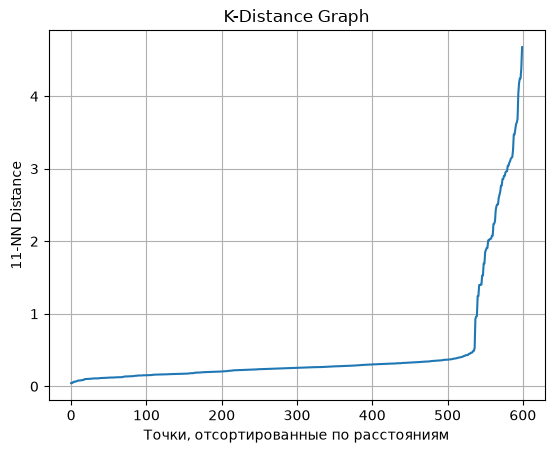

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Строим K-Distance Graph
nn = NearestNeighbors(n_neighbors = 11)
model = nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances, axis=0)
distances = distances[:,1]

# рисуем график
plt.grid()
plt.plot(distances)
plt.xlabel('Точки, отсортированные по расстояниям')
plt.ylabel('11-NN Distance')
plt.title('K-Distance Graph')
plt.show()